In [ ]:
import os
from pathlib import Path
import pickle
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Masking, LSTM, Dropout, Dense
from tensorflow.keras.models import load_model
from tensorflow.keras.regularizers import l2

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Preprocessing

## Create label mapping

In [3]:
data_dir = Path("/content/drive/MyDrive/Lip Landmark Dataset/landmark_dataset")

train_data_dir = data_dir / "train"
test_data_dir = data_dir / "test"

In [4]:
SEQUENCE_LENGTH = 16
FEATURE_DIM = 80

INPUT_SHAPE = (SEQUENCE_LENGTH, FEATURE_DIM)

In [5]:
vocab_words = [
    'again', 'at', 'bin', 'blue', 'by',
    'green', 'in', 'lay', 'now',
    'place', 'please', 'red',
    'set', 'soon', 'white', 'with'
]

In [6]:
words = sorted([f.name for f in train_data_dir.iterdir() if f.is_dir() and f.name in vocab_words])
word_to_idx = {word: i for i, word in enumerate(words)}
idx_to_word = {i: word for word, i in word_to_idx.items()}

print(word_to_idx)

{'again': 0, 'at': 1, 'bin': 2, 'blue': 3, 'by': 4, 'green': 5, 'in': 6, 'lay': 7, 'now': 8, 'place': 9, 'please': 10, 'red': 11, 'set': 12, 'soon': 13, 'white': 14, 'with': 15}


In [ ]:
counts = {}

for word in words:
    word_dir = train_data_dir / word
    num_samples = len(list(word_dir.glob("*.npy")))
    counts[word] = num_samples

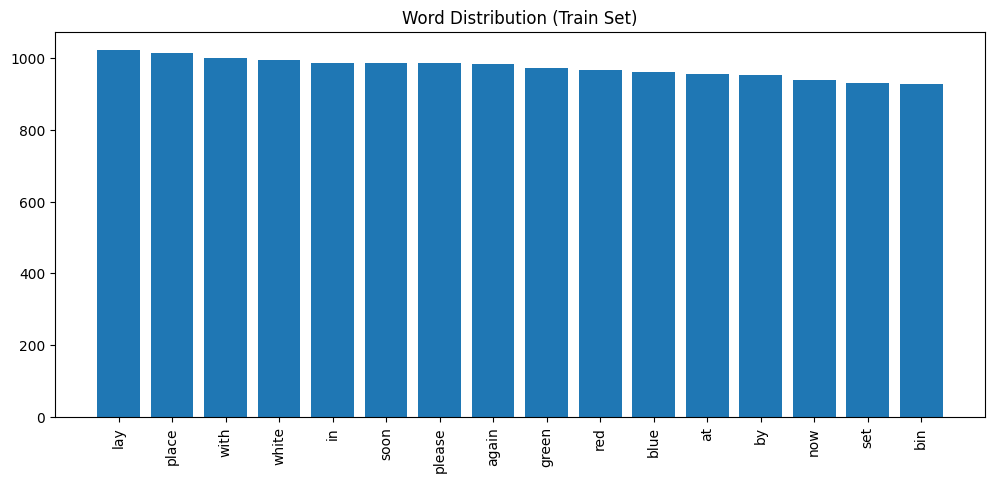

In [ ]:
sorted_items = sorted(counts.items(), key=lambda x: x[1], reverse=True)

words = [item[0] for item in sorted_items]
values = [item[1] for item in sorted_items]

plt.figure(figsize=(12,5))
plt.bar(words, values)
plt.xticks(rotation=90)
plt.title("Word Distribution (Train Set)")
plt.show()

## Split dataset into input/output

In [ ]:
def build_dataset_arrays(train_data_dir, test_data_dir, words, word_to_idx, input_shape):
    x_train, y_train = [], []
    x_test, y_test = [], []

    train_data_dir = Path(train_data_dir)
    test_data_dir = Path(test_data_dir)

    for word in tqdm(words, desc="Loading data"):
        train_word_dir = train_data_dir / word
        test_word_dir = test_data_dir / word

        # ---- TRAIN ----
        if train_word_dir.exists():
            for file in train_word_dir.glob("*.npy"):
                try:
                    arr = np.load(file)

                    if arr.shape != input_shape:
                        continue

                    x_train.append(arr)
                    y_train.append(word_to_idx[word])

                except Exception:
                    continue

        # ---- TEST ----
        if test_word_dir.exists():
            for file in test_word_dir.glob("*.npy"):
                try:
                    arr = np.load(file)

                    if arr.shape != input_shape:
                        continue

                    x_test.append(arr)
                    y_test.append(word_to_idx[word])

                except Exception:
                    continue

    # Convert to numpy
    x_train = np.array(x_train, dtype=np.float32)
    y_train = np.array(y_train)

    x_test = np.array(x_test, dtype=np.float32)
    y_test = np.array(y_test)

    return x_train, y_train, x_test, y_test

In [ ]:
x_train, y_train, x_test, y_test = build_dataset_arrays(
    train_data_dir=train_data_dir,
    test_data_dir=test_data_dir,
    words=words,
    word_to_idx=word_to_idx,
    input_shape=INPUT_SHAPE
)

Loading data: 100%|██████████| 16/16 [03:47<00:00, 14.19s/it]


In [7]:
def save_dataset(data_dir, x_train, y_train, x_test, y_test):
    data_dir = Path(data_dir)
    data_dir.mkdir(parents=True, exist_ok=True)

    np.save(data_dir / "x_train.npy", x_train)
    np.save(data_dir / "y_train.npy", y_train)
    np.save(data_dir / "x_test.npy", x_test)
    np.save(data_dir / "y_test.npy", y_test)

    print(f"[INFO] Dataset saved to {data_dir}")

def load_dataset(data_dir):
    data_dir = Path(data_dir)

    x_train = np.load(data_dir / "x_train.npy")
    y_train = np.load(data_dir / "y_train.npy")
    x_test  = np.load(data_dir / "x_test.npy")
    y_test  = np.load(data_dir / "y_test.npy")

    print(f"[INFO] Dataset loaded from {data_dir}")

    return x_train, y_train, x_test, y_test

In [ ]:
save_dataset(data_dir, x_train, y_train, x_test, y_test)

In [9]:
x_train, y_train, x_test, y_test = load_dataset(data_dir)

[INFO] Dataset loaded from /content/drive/MyDrive/Lip Landmark Dataset/landmark_dataset


In [10]:
print(f"[INFO] Train: {x_train.shape}, {y_train.shape}")
print(f"[INFO] Test : {x_test.shape}, {y_test.shape}")

[INFO] Train: (15588, 16, 80), (15588,)
[INFO] Test : (3600, 16, 80), (3600,)


# Model Creation

In [15]:
model = Sequential([
    Input(shape=INPUT_SHAPE),
    Masking(mask_value=0.0),

    LSTM(128, return_sequences=True, recurrent_dropout=0.2),
    Dropout(0.3),

    LSTM(64),
    Dropout(0.3),

    Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
    Dense(len(words), activation='softmax')
])

In [16]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [17]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking_1 (Masking)             │ (None, 16, 80)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 16, 128)        │       107,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │         1,040 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 161,616 (631.31 KB)

 Trainable params: 161,616 (631.31 KB)

 Non-trainable params: 0 (0.00 B)

## Model Training

In [18]:
history = model.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    epochs=30,
    batch_size=32
)

Epoch 1/30
488/488 ━━━━━━━━━━━━━━━━━━━━ 42s 79ms/step - accuracy: 0.2043 - loss: 2.3016 - val_accuracy: 0.2703 - val_loss: 2.0307
Epoch 2/30
488/488 ━━━━━━━━━━━━━━━━━━━━ 37s 76ms/step - accuracy: 0.2818 - loss: 2.0422 - val_accuracy: 0.3025 - val_loss: 1.9455
Epoch 3/30
488/488 ━━━━━━━━━━━━━━━━━━━━ 37s 76ms/step - accuracy: 0.3371 - loss: 1.8950 - val_accuracy: 0.3769 - val_loss: 1.8722
Epoch 4/30
488/488 ━━━━━━━━━━━━━━━━━━━━ 38s 77ms/step - accuracy: 0.4022 - loss: 1.7260 - val_accuracy: 0.4206 - val_loss: 1.7446
Epoch 5/30
488/488 ━━━━━━━━━━━━━━━━━━━━ 36s 73ms/step - accuracy: 0.4379 - loss: 1.6148 - val_accuracy: 0.4289 - val_loss: 1.6953
Epoch 6/30
488/488 ━━━━━━━━━━━━━━━━━━━━ 41s 74ms/step - accuracy: 0.4710 - loss: 1.5381 - val_accuracy: 0.4561 - val_loss: 1.6455
Epoch 7/30
488/488 ━━━━━━━━━━━━━━━━━━━━ 41s 75ms/step - accuracy: 0.4858 - loss: 1.4779 - val_accuracy: 0.4611 - val_loss: 1.5912
Epoch 8/30
488/488 ━━━━━━━━━━━━━━━━━━━━ 41s 74ms/step - accuracy: 0.4981 - loss: 1.4404 - 

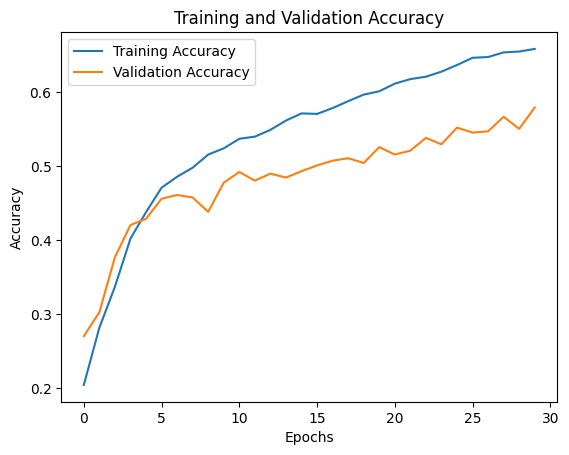

In [19]:
plt.plot(history.history['accuracy'], label='Training Accuracy')

plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

## Saving the model

In [20]:
model.save("lip_reading_model.h5")

In [21]:
with open("label_map.pkl", "wb") as f:
    pickle.dump(word_to_idx, f)

# Load model for inference

In [ ]:
model = load_model("lip_reading_model.h5")

with open("label_map.pkl", "rb") as f:
    word_to_idx = pickle.load(f)

idx_to_word = {v: k for k, v in word_to_idx.items()}